# SOH vs SOC Throughput EDA

This notebook tests a specific hypothesis: large upward SOH jumps may be associated with high battery usage.

For this notebook, **SOC throughput** is defined as the absolute SOC movement within an event:

$$\text{soc\_throughput} = |SOC_{end} - SOC_{start}|$$

We look at three related questions:

1. Do large SOH jumps happen on high-throughput events?
2. Do they happen after periods of high recent cumulative throughput?
3. Are the results different for charging vs flight events?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'EDA' else Path.cwd().resolve()
TIMESERIES_PATH = PROJECT_ROOT / 'data' / 'event_timeseries.parquet'

PLANE_FOCUS = '166'
SPIKE_THRESHOLD_PCT = 2.0
SOC_EDGE_SAMPLES = 25

plt.style.use('default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

TIMESERIES_PATH

PosixPath('/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/data/event_timeseries.parquet')

## Build an event-level table

We use aux rows only, then collapse each `(plane, battery, event)` into one row with:

- `observed_soh_pct`: median event SOH
- `soc_start_pct`: median of the first few SOC samples
- `soc_end_pct`: median of the last few SOC samples
- `soc_throughput_pct`: absolute SOC movement within the event
- `delta_soh_pct`: event-to-event SOH change within a battery timeline
- rolling recent throughput over the last 5 events, 10 events, and 30 days

In [2]:
def classify_event_type(frame: pd.DataFrame) -> str:
    is_charge = int(frame['is_charging_event'].max())
    is_flight = int(frame['is_flight_event'].max())
    if is_charge and not is_flight:
        return 'charge'
    if is_flight and not is_charge:
        return 'flight'
    if is_charge and is_flight:
        return 'mixed'
    return 'other'


def build_event_table(timeseries_path: Path, edge_samples: int = 25) -> pd.DataFrame:
    cols = [
        'plane_id',
        'flight_id',
        'event_datetime',
        'source_csv_kind',
        'source_pack_id',
        'is_charging_event',
        'is_flight_event',
        'time_ms',
        ' bat 1 soh',
        ' bat 2 soh',
        ' bat 1 soc',
        ' bat 2 soc',
    ]
    raw = pd.read_parquet(timeseries_path, columns=cols)
    raw = raw[raw['source_csv_kind'].eq('aux') & raw['source_pack_id'].isin([1, 2])].copy()
    raw['event_datetime'] = pd.to_datetime(raw['event_datetime'])
    raw = raw.dropna(subset=['event_datetime'])

    rows = []
    for battery_id in [1, 2]:
        battery = raw[raw['source_pack_id'].eq(battery_id)].copy()
        soh_col = f' bat {battery_id} soh'
        soc_col = f' bat {battery_id} soc'
        battery[soh_col] = pd.to_numeric(battery[soh_col], errors='coerce')
        battery[soc_col] = pd.to_numeric(battery[soc_col], errors='coerce')
        battery = battery.sort_values(['plane_id', 'event_datetime', 'flight_id', 'time_ms'])

        for (plane_id, flight_id, event_datetime), group in battery.groupby(
            ['plane_id', 'flight_id', 'event_datetime'],
            sort=False,
        ):
            soc = group[soc_col].dropna().to_numpy()
            soh = group[soh_col].dropna().to_numpy()
            start = np.nan
            end = np.nan
            if soc.size:
                k = min(edge_samples, soc.size)
                start = float(np.nanmedian(soc[:k]))
                end = float(np.nanmedian(soc[-k:]))
            rows.append(
                {
                    'plane_id': str(plane_id),
                    'battery_id': battery_id,
                    'flight_id': int(flight_id),
                    'event_datetime': event_datetime,
                    'event_type': classify_event_type(group),
                    'is_charging_event': int(group['is_charging_event'].max()),
                    'is_flight_event': int(group['is_flight_event'].max()),
                    'observed_soh_pct': float(np.nanmedian(soh)) if soh.size else np.nan,
                    'soc_start_pct': start,
                    'soc_end_pct': end,
                    'soc_throughput_pct': float(abs(end - start)) if np.isfinite(start) and np.isfinite(end) else np.nan,
                    'soc_signed_delta_pct': float(end - start) if np.isfinite(start) and np.isfinite(end) else np.nan,
                    'n_rows': int(len(group)),
                }
            )

    events = pd.DataFrame(rows)
    events = events.sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)

    per_battery = []
    for (plane_id, battery_id), group in events.groupby(['plane_id', 'battery_id'], sort=False):
        group = group.sort_values(['event_datetime', 'flight_id']).copy()
        group['event_index'] = np.arange(len(group))
        group['delta_soh_pct'] = group['observed_soh_pct'].diff()
        group['spike_up'] = group['delta_soh_pct'] >= SPIKE_THRESHOLD_PCT
        group['spike_down'] = group['delta_soh_pct'] <= -SPIKE_THRESHOLD_PCT
        group['rolling_soc_throughput_5'] = group['soc_throughput_pct'].rolling(5, min_periods=1).sum()
        group['rolling_soc_throughput_10'] = group['soc_throughput_pct'].rolling(10, min_periods=1).sum()
        group = group.set_index('event_datetime')
        group['recent_soc_throughput_30d'] = group['soc_throughput_pct'].rolling('30D', min_periods=1).sum()
        group['recent_soc_throughput_7d'] = group['soc_throughput_pct'].rolling('7D', min_periods=1).sum()
        group['recent_event_count_30d'] = pd.Series(1.0, index=group.index).rolling('30D', min_periods=1).sum()
        group['recent_event_count_7d'] = pd.Series(1.0, index=group.index).rolling('7D', min_periods=1).sum()
        group['recent_charge_count_30d'] = group['event_type'].eq('charge').astype(float).rolling('30D', min_periods=1).sum()
        group['recent_flight_count_30d'] = group['event_type'].eq('flight').astype(float).rolling('30D', min_periods=1).sum()
        group = group.reset_index()
        per_battery.append(group)

    return pd.concat(per_battery, ignore_index=True)


event_df = build_event_table(TIMESERIES_PATH, edge_samples=SOC_EDGE_SAMPLES)
display(event_df.head())
display(event_df.groupby(['plane_id', 'battery_id']).agg(
    n_events=('flight_id', 'size'),
    n_spikes=('spike_up', 'sum'),
    median_throughput=('soc_throughput_pct', 'median'),
    median_delta_soh=('delta_soh_pct', 'median'),
).reset_index())

,event_datetime,plane_id,battery_id,flight_id,event_type,is_charging_event,is_flight_event,observed_soh_pct,soc_start_pct,soc_end_pct,soc_throughput_pct,soc_signed_delta_pct,n_rows,event_index,delta_soh_pct,spike_up,spike_down,rolling_soc_throughput_5,rolling_soc_throughput_10,recent_soc_throughput_30d,recent_soc_throughput_7d,recent_event_count_30d,recent_event_count_7d,recent_charge_count_30d,recent_flight_count_30d
0,2023-05-16 11:00:00,166,1,4575,charge,1,0,100.0,77.0,100.0,23.0,23.0,15745,0,NaN,False,False,23.0,23.0,23.0,23.0,1.0,1.0,1.0,0.0
1,2023-05-16 12:44:00,166,1,4576,other,0,0,100.0,100.0,29.0,71.0,-71.0,9638,1,0.0,False,False,94.0,94.0,94.0,94.0,2.0,2.0,1.0,0.0
2,2023-05-16 13:00:00,166,1,4577,charge,1,0,97.0,29.0,100.0,71.0,71.0,18774,2,-3.0,False,True,165.0,165.0,165.0,165.0,3.0,3.0,2.0,0.0
3,2023-05-16 14:35:00,166,1,4578,other,0,0,97.0,100.0,29.0,71.0,-71.0,11409,3,0.0,False,False,236.0,236.0,236.0,236.0,4.0,4.0,2.0,0.0
4,2023-05-16 15:00:00,166,1,4579,charge,1,0,96.0,29.0,100.0,71.0,71.0,20922,4,-1.0,False,False,307.0,307.0,307.0,307.0,5.0,5.0,3.0,0.0


,plane_id,battery_id,n_events,n_spikes,median_throughput,median_delta_soh
0,166,1,553,35,52.0,0.0
1,166,2,553,37,51.0,0.0
2,192,1,49,0,50.0,0.0
3,192,2,49,0,50.0,0.0


## Focus plane overview

First look at raw SOH and per-event SOC throughput over time for the selected plane.

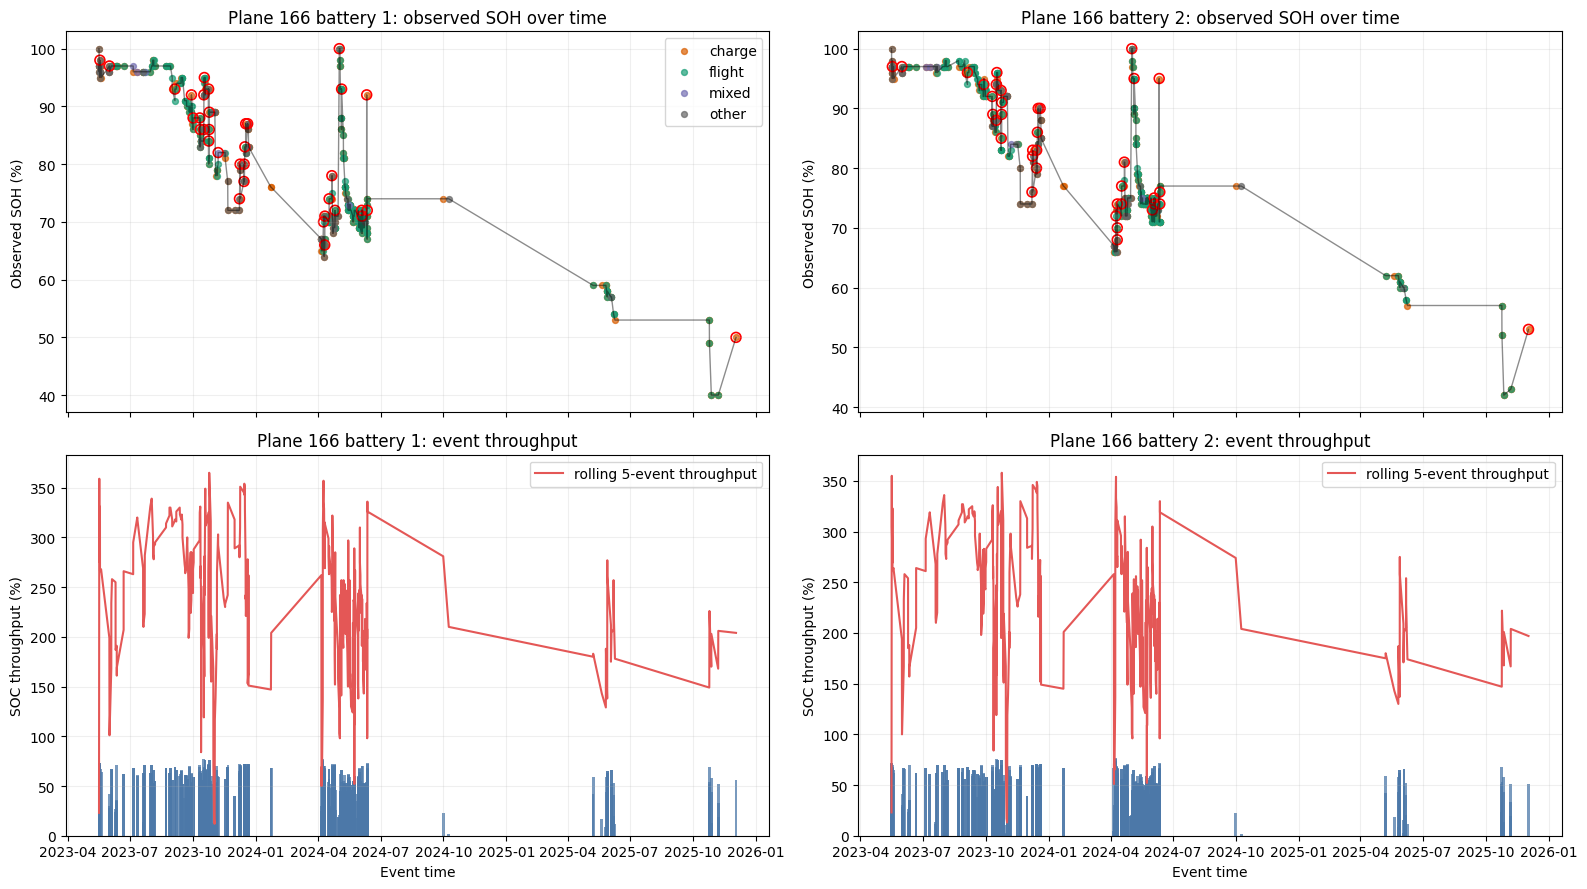

In [3]:
focus = event_df[event_df['plane_id'].eq(PLANE_FOCUS)].copy()
colors = {'charge': '#d95f02', 'flight': '#1b9e77', 'mixed': '#7570b3', 'other': '#666666'}

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col')
for i, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    ax_soh = axes[0, i]
    ax_thr = axes[1, i]

    for event_type, sub in g.groupby('event_type'):
        ax_soh.scatter(sub['event_datetime'], sub['observed_soh_pct'], s=18, alpha=0.7, label=event_type, color=colors.get(event_type, '#444444'))
    ax_soh.plot(g['event_datetime'], g['observed_soh_pct'], color='black', linewidth=1.0, alpha=0.45)
    spike = g[g['spike_up']]
    ax_soh.scatter(spike['event_datetime'], spike['observed_soh_pct'], s=50, facecolors='none', edgecolors='red', linewidth=1.2)
    ax_soh.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: observed SOH over time')
    ax_soh.set_ylabel('Observed SOH (%)')
    ax_soh.grid(alpha=0.2)

    ax_thr.bar(g['event_datetime'], g['soc_throughput_pct'], color='#4c78a8', alpha=0.75, width=4)
    ax_thr.plot(g['event_datetime'], g['rolling_soc_throughput_5'], color='#e45756', linewidth=1.5, label='rolling 5-event throughput')
    ax_thr.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: event throughput')
    ax_thr.set_ylabel('SOC throughput (%)')
    ax_thr.grid(alpha=0.2)
    ax_thr.legend(loc='upper right')

axes[0, 0].legend(loc='upper right')
axes[1, 0].set_xlabel('Event time')
axes[1, 1].set_xlabel('Event time')
plt.tight_layout()
plt.show()

## Same view by event index

This is useful when calendar gaps make the time-axis harder to read.

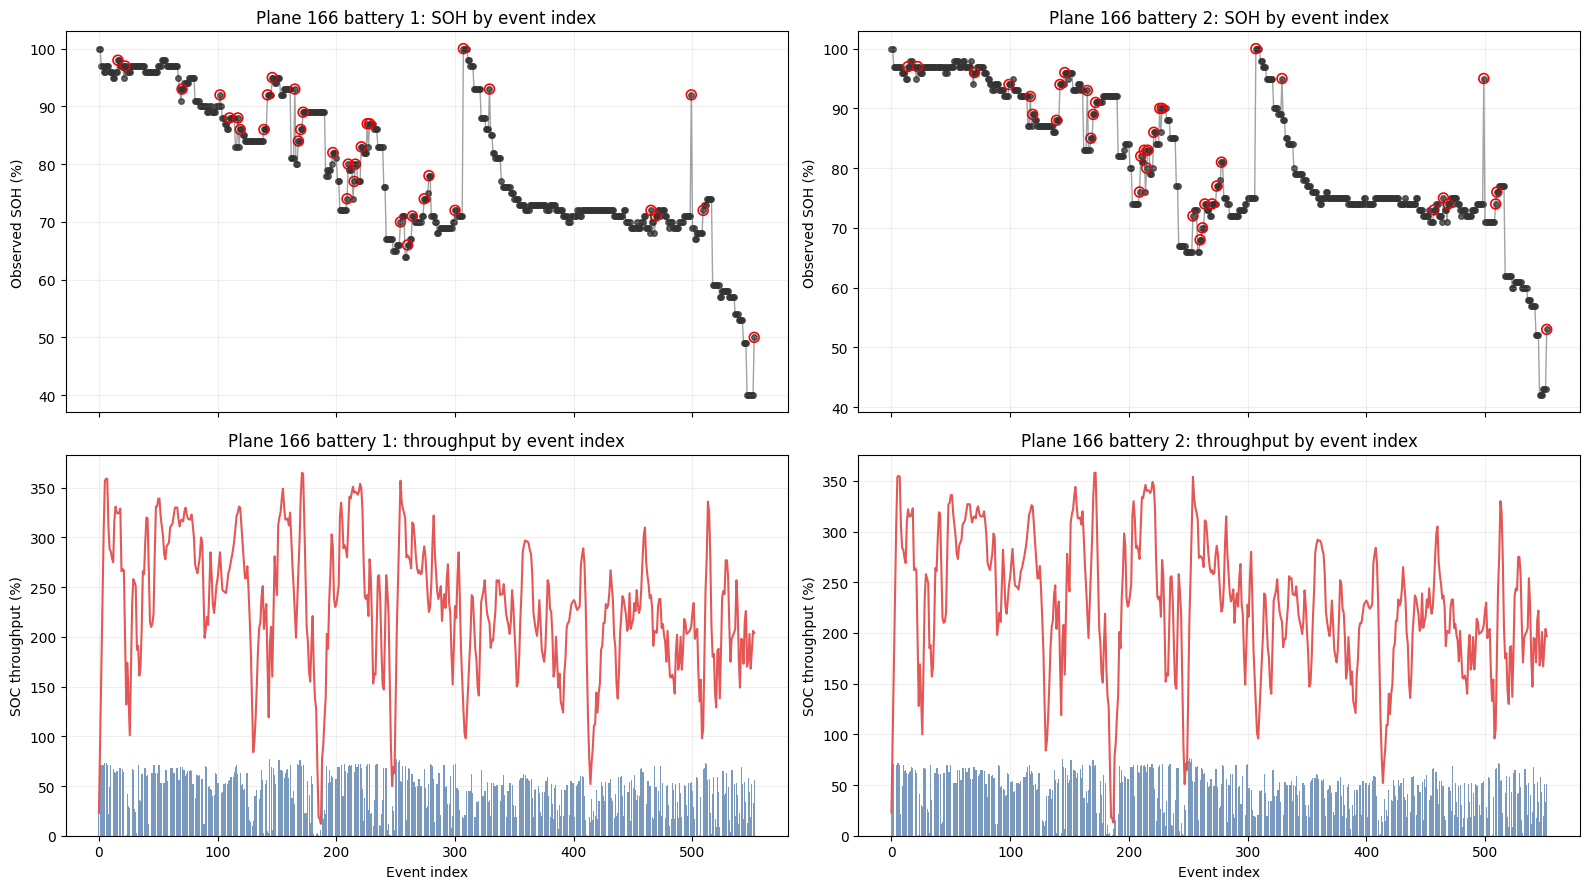

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col')
for i, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    ax_soh = axes[0, i]
    ax_thr = axes[1, i]

    ax_soh.scatter(g['event_index'], g['observed_soh_pct'], s=16, color='#333333', alpha=0.75)
    ax_soh.plot(g['event_index'], g['observed_soh_pct'], color='#333333', linewidth=1.0, alpha=0.45)
    spike = g[g['spike_up']]
    ax_soh.scatter(spike['event_index'], spike['observed_soh_pct'], s=50, facecolors='none', edgecolors='red', linewidth=1.2)
    ax_soh.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: SOH by event index')
    ax_soh.set_ylabel('Observed SOH (%)')
    ax_soh.grid(alpha=0.2)

    ax_thr.bar(g['event_index'], g['soc_throughput_pct'], color='#4c78a8', alpha=0.75)
    ax_thr.plot(g['event_index'], g['rolling_soc_throughput_5'], color='#e45756', linewidth=1.5)
    ax_thr.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: throughput by event index')
    ax_thr.set_ylabel('SOC throughput (%)')
    ax_thr.set_xlabel('Event index')
    ax_thr.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Correlation summary

We compare event-to-event SOH change with:

- current-event SOC throughput
- rolling 5-event throughput
- rolling 10-event throughput
- recent 7-day throughput
- recent 30-day throughput

In [5]:
summary_rows = []
for (plane_id, battery_id), g in event_df.groupby(['plane_id', 'battery_id']):
    g = g.copy()
    row = {
        'plane_id': plane_id,
        'battery_id': battery_id,
        'n_events': len(g),
        'n_spikes_up': int(g['spike_up'].sum()),
        'corr_delta_soh_vs_event_throughput': g['delta_soh_pct'].corr(g['soc_throughput_pct'], method='spearman'),
        'corr_delta_soh_vs_rolling_5': g['delta_soh_pct'].corr(g['rolling_soc_throughput_5'], method='spearman'),
        'corr_delta_soh_vs_rolling_10': g['delta_soh_pct'].corr(g['rolling_soc_throughput_10'], method='spearman'),
        'corr_delta_soh_vs_recent_7d': g['delta_soh_pct'].corr(g['recent_soc_throughput_7d'], method='spearman'),
        'corr_delta_soh_vs_recent_30d': g['delta_soh_pct'].corr(g['recent_soc_throughput_30d'], method='spearman'),
        'median_event_throughput_spike': g.loc[g['spike_up'], 'soc_throughput_pct'].median(),
        'median_event_throughput_non_spike': g.loc[~g['spike_up'], 'soc_throughput_pct'].median(),
        'median_rolling5_spike': g.loc[g['spike_up'], 'rolling_soc_throughput_5'].median(),
        'median_rolling5_non_spike': g.loc[~g['spike_up'], 'rolling_soc_throughput_5'].median(),
        'corr_delta_soh_vs_event_count_30d': g['delta_soh_pct'].corr(g['recent_event_count_30d'], method='spearman'),
        'corr_delta_soh_vs_charge_count_30d': g['delta_soh_pct'].corr(g['recent_charge_count_30d'], method='spearman'),
        'corr_delta_soh_vs_flight_count_30d': g['delta_soh_pct'].corr(g['recent_flight_count_30d'], method='spearman'),
        'median_event_count_30d_spike': g.loc[g['spike_up'], 'recent_event_count_30d'].median(),
        'median_event_count_30d_non_spike': g.loc[~g['spike_up'], 'recent_event_count_30d'].median(),
    }
    summary_rows.append(row)

corr_summary = pd.DataFrame(summary_rows).sort_values(['plane_id', 'battery_id']).reset_index(drop=True)
display(corr_summary.round(3))

,plane_id,battery_id,n_events,n_spikes_up,corr_delta_soh_vs_event_throughput,corr_delta_soh_vs_rolling_5,corr_delta_soh_vs_rolling_10,corr_delta_soh_vs_recent_7d,corr_delta_soh_vs_recent_30d,median_event_throughput_spike,median_event_throughput_non_spike,median_rolling5_spike,median_rolling5_non_spike,corr_delta_soh_vs_event_count_30d,corr_delta_soh_vs_charge_count_30d,corr_delta_soh_vs_flight_count_30d,median_event_count_30d_spike,median_event_count_30d_non_spike
0,166,1,553,35,0.101,0.082,0.037,0.050,0.040,62.0,51.0,278.0,233.0,0.036,0.031,0.037,42.0,60.0
1,166,2,553,37,0.069,0.068,0.029,0.044,0.038,62.0,50.0,262.0,229.5,0.034,0.029,0.032,33.0,60.0
2,192,1,49,0,0.167,0.207,0.101,0.047,0.032,NaN,50.0,NaN,218.0,0.032,0.012,0.069,NaN,25.0
3,192,2,49,0,-0.065,0.063,0.105,0.013,0.099,NaN,50.0,NaN,218.0,0.102,0.074,0.148,NaN,25.0


## Event counts over a 30-day window

This section tests a slightly different idea from throughput.

Instead of asking whether large SOH jumps happen after a lot of SOC movement, we ask whether they happen after **high event frequency**:

- total event count in the last 30 days
- charging-event count in the last 30 days
- flight-event count in the last 30 days

If regular usage frequency is inflating the BMS SOH estimate, the spike events should cluster at unusually high recent event counts.

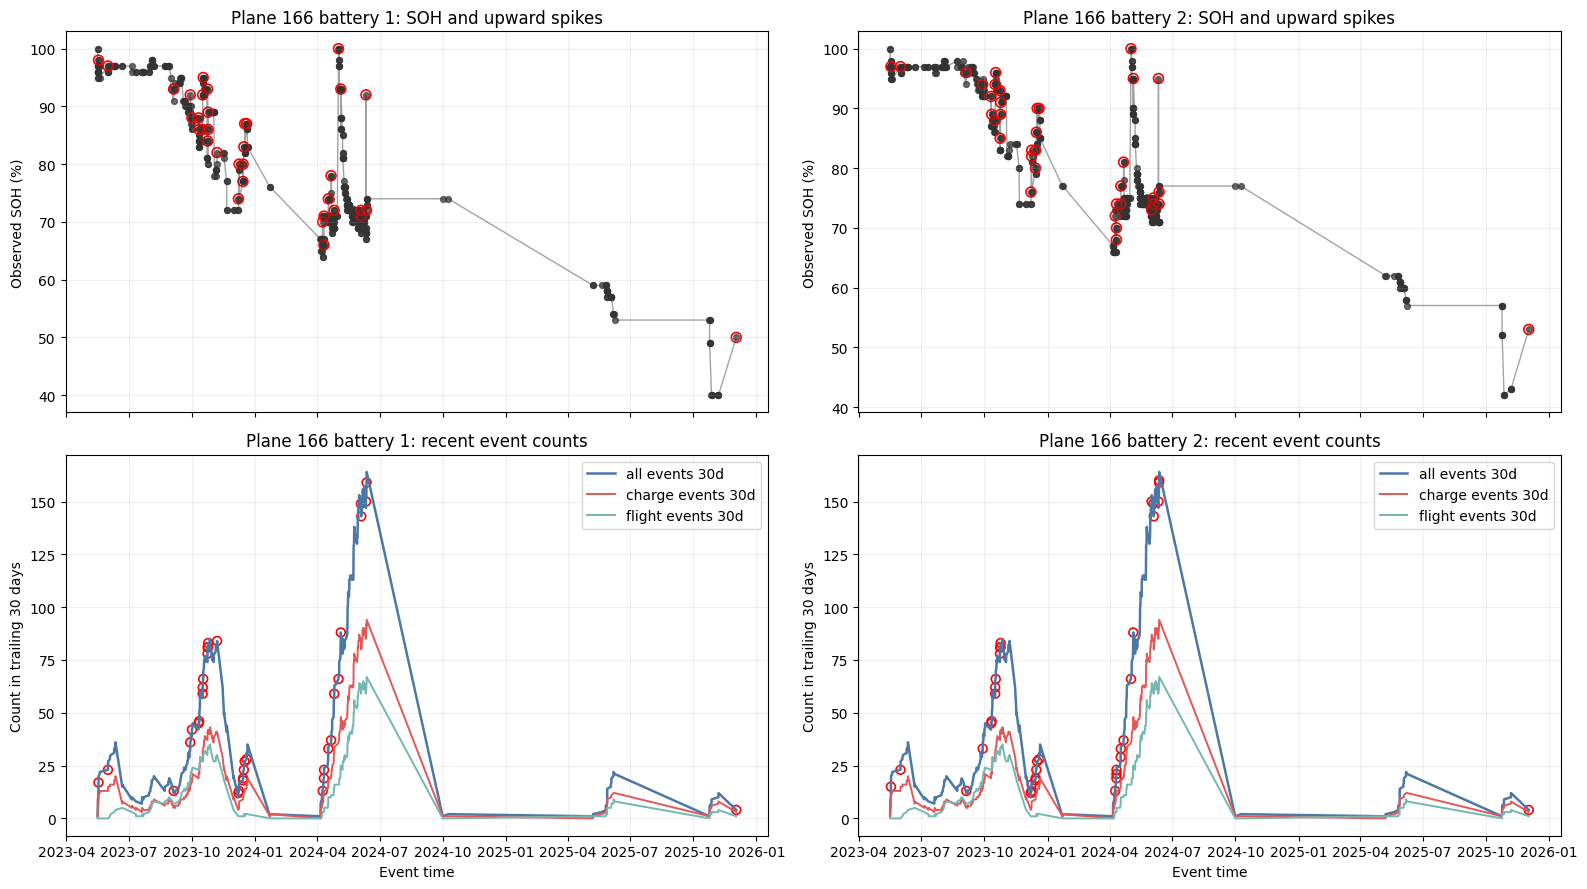

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col')
for i, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    ax_soh = axes[0, i]
    ax_cnt = axes[1, i]

    ax_soh.scatter(g['event_datetime'], g['observed_soh_pct'], s=18, alpha=0.7, color='#333333')
    ax_soh.plot(g['event_datetime'], g['observed_soh_pct'], color='#333333', linewidth=1.0, alpha=0.45)
    spike = g[g['spike_up']]
    ax_soh.scatter(spike['event_datetime'], spike['observed_soh_pct'], s=50, facecolors='none', edgecolors='red', linewidth=1.2)
    ax_soh.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: SOH and upward spikes')
    ax_soh.set_ylabel('Observed SOH (%)')
    ax_soh.grid(alpha=0.2)

    ax_cnt.plot(g['event_datetime'], g['recent_event_count_30d'], color='#4c78a8', linewidth=1.8, label='all events 30d')
    ax_cnt.plot(g['event_datetime'], g['recent_charge_count_30d'], color='#e45756', linewidth=1.4, label='charge events 30d')
    ax_cnt.plot(g['event_datetime'], g['recent_flight_count_30d'], color='#72b7b2', linewidth=1.4, label='flight events 30d')
    ax_cnt.scatter(spike['event_datetime'], spike['recent_event_count_30d'], s=40, facecolors='none', edgecolors='red', linewidth=1.2)
    ax_cnt.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: recent event counts')
    ax_cnt.set_ylabel('Count in trailing 30 days')
    ax_cnt.grid(alpha=0.2)
    ax_cnt.legend(loc='upper right')

axes[1, 0].set_xlabel('Event time')
axes[1, 1].set_xlabel('Event time')
plt.tight_layout()
plt.show()

/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_66839/984732048.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_66839/984732048.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(


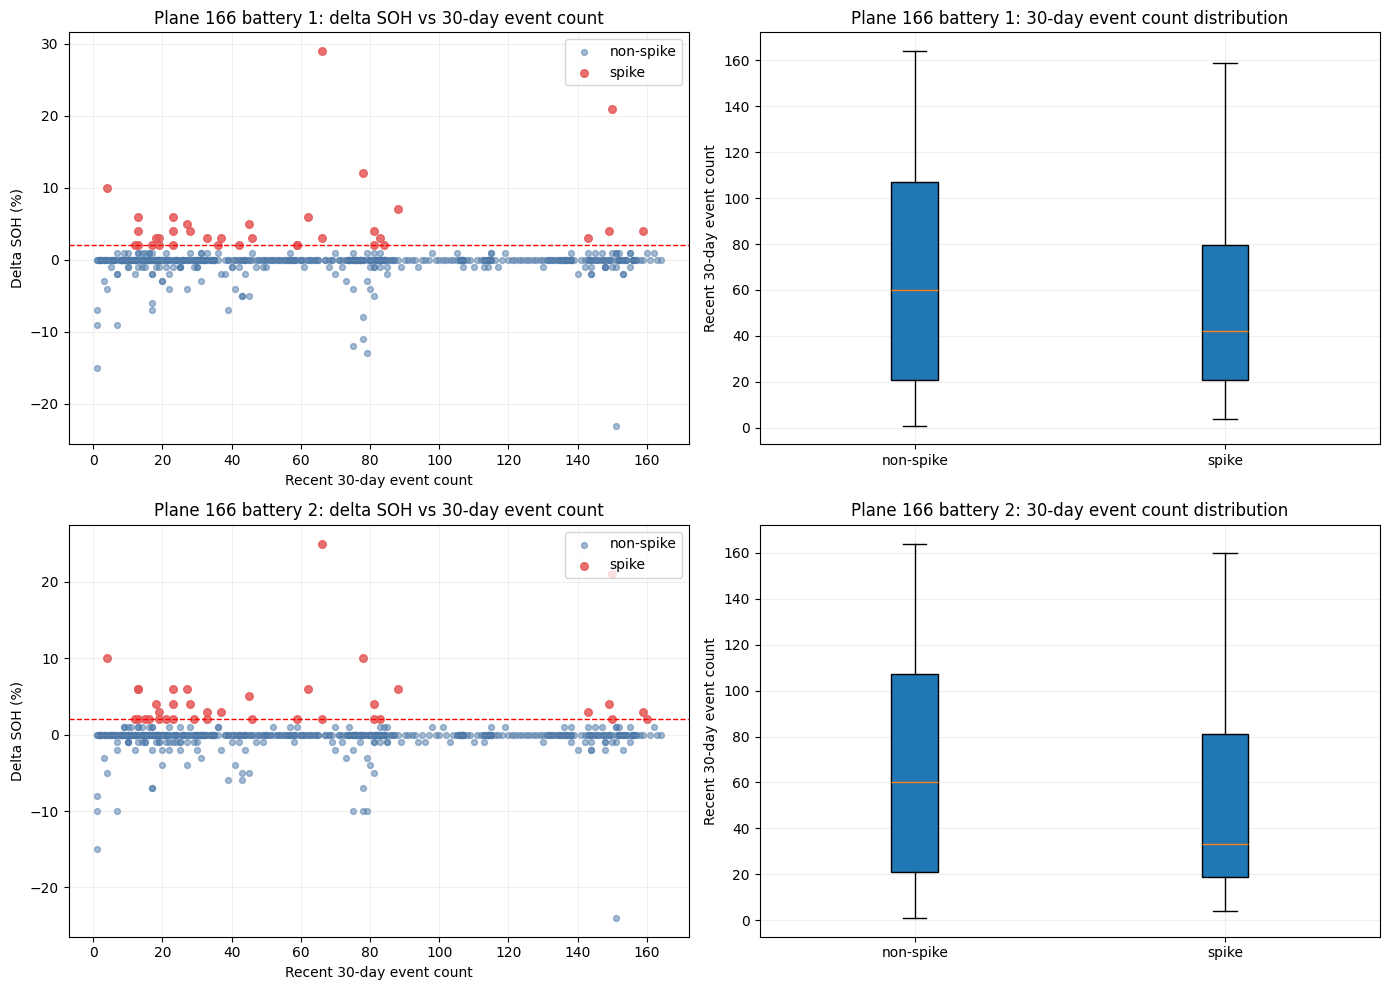

/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_66839/984732048.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,battery_id,corr_delta_soh_vs_event_count_30d,corr_delta_soh_vs_charge_count_30d,corr_delta_soh_vs_flight_count_30d,median_event_count_30d_spike,median_event_count_30d_non_spike,median_charge_count_30d_spike,median_charge_count_30d_non_spike,median_flight_count_30d_spike,median_flight_count_30d_non_spike
0,1,0.036,0.031,0.037,42.0,60.0,20.0,30.5,16.0,23.0
1,2,0.034,0.029,0.032,33.0,60.0,18.0,31.0,11.0,23.0


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_idx, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].copy()
    spike = g['spike_up']
    ax1 = axes[row_idx, 0]
    ax2 = axes[row_idx, 1]

    ax1.scatter(g.loc[~spike, 'recent_event_count_30d'], g.loc[~spike, 'delta_soh_pct'], s=18, alpha=0.5, color='#4c78a8', label='non-spike')
    ax1.scatter(g.loc[spike, 'recent_event_count_30d'], g.loc[spike, 'delta_soh_pct'], s=30, alpha=0.85, color='#e45756', label='spike')
    ax1.axhline(SPIKE_THRESHOLD_PCT, color='red', linestyle='--', linewidth=1.0)
    ax1.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: delta SOH vs 30-day event count')
    ax1.set_xlabel('Recent 30-day event count')
    ax1.set_ylabel('Delta SOH (%)')
    ax1.grid(alpha=0.2)
    ax1.legend(loc='upper right')

    ax2.boxplot(
        [g.loc[~spike, 'recent_event_count_30d'].dropna(), g.loc[spike, 'recent_event_count_30d'].dropna()],
        labels=['non-spike', 'spike'],
        patch_artist=True,
    )
    ax2.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: 30-day event count distribution')
    ax2.set_ylabel('Recent 30-day event count')
    ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

count_summary = (
    focus.groupby('battery_id')
    .apply(
        lambda g: pd.Series({
            'corr_delta_soh_vs_event_count_30d': g['delta_soh_pct'].corr(g['recent_event_count_30d'], method='spearman'),
            'corr_delta_soh_vs_charge_count_30d': g['delta_soh_pct'].corr(g['recent_charge_count_30d'], method='spearman'),
            'corr_delta_soh_vs_flight_count_30d': g['delta_soh_pct'].corr(g['recent_flight_count_30d'], method='spearman'),
            'median_event_count_30d_spike': g.loc[g['spike_up'], 'recent_event_count_30d'].median(),
            'median_event_count_30d_non_spike': g.loc[~g['spike_up'], 'recent_event_count_30d'].median(),
            'median_charge_count_30d_spike': g.loc[g['spike_up'], 'recent_charge_count_30d'].median(),
            'median_charge_count_30d_non_spike': g.loc[~g['spike_up'], 'recent_charge_count_30d'].median(),
            'median_flight_count_30d_spike': g.loc[g['spike_up'], 'recent_flight_count_30d'].median(),
            'median_flight_count_30d_non_spike': g.loc[~g['spike_up'], 'recent_flight_count_30d'].median(),
        })
    )
    .reset_index()
)
display(count_summary.round(3))

## Scatter plots: SOH jump vs throughput

These plots make it easy to see whether spikes simply happen at the high end of throughput.

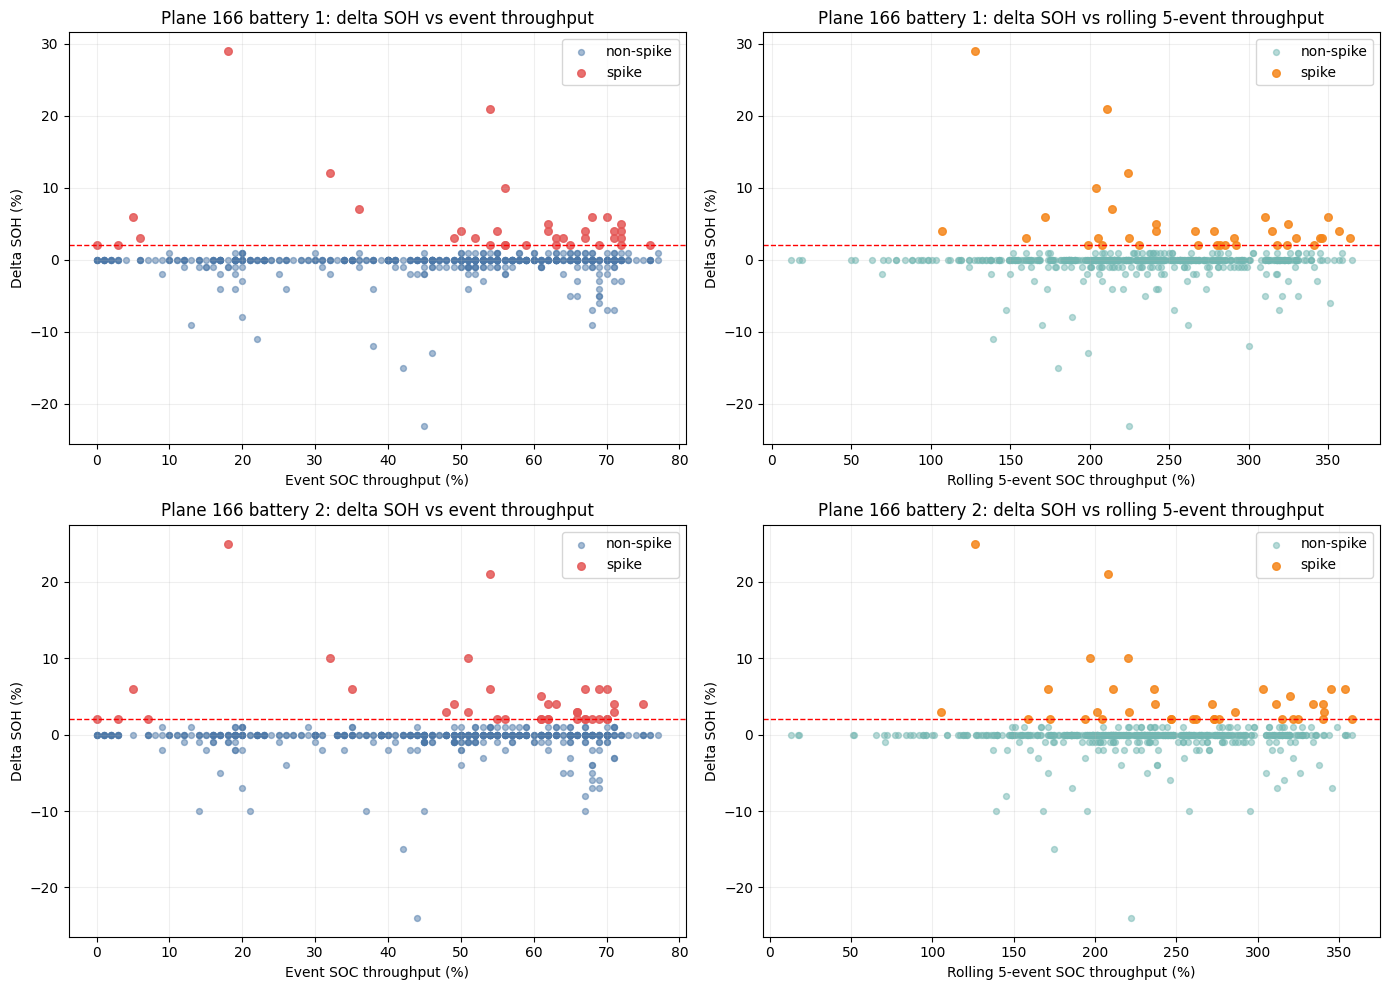

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_idx, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].copy()
    ax1 = axes[row_idx, 0]
    ax2 = axes[row_idx, 1]

    spike = g['spike_up']
    ax1.scatter(g.loc[~spike, 'soc_throughput_pct'], g.loc[~spike, 'delta_soh_pct'], s=18, alpha=0.5, color='#4c78a8', label='non-spike')
    ax1.scatter(g.loc[spike, 'soc_throughput_pct'], g.loc[spike, 'delta_soh_pct'], s=30, alpha=0.85, color='#e45756', label='spike')
    ax1.axhline(SPIKE_THRESHOLD_PCT, color='red', linestyle='--', linewidth=1.0)
    ax1.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: delta SOH vs event throughput')
    ax1.set_xlabel('Event SOC throughput (%)')
    ax1.set_ylabel('Delta SOH (%)')
    ax1.grid(alpha=0.2)
    ax1.legend(loc='upper right')

    ax2.scatter(g.loc[~spike, 'rolling_soc_throughput_5'], g.loc[~spike, 'delta_soh_pct'], s=18, alpha=0.5, color='#72b7b2', label='non-spike')
    ax2.scatter(g.loc[spike, 'rolling_soc_throughput_5'], g.loc[spike, 'delta_soh_pct'], s=30, alpha=0.85, color='#f58518', label='spike')
    ax2.axhline(SPIKE_THRESHOLD_PCT, color='red', linestyle='--', linewidth=1.0)
    ax2.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: delta SOH vs rolling 5-event throughput')
    ax2.set_xlabel('Rolling 5-event SOC throughput (%)')
    ax2.set_ylabel('Delta SOH (%)')
    ax2.grid(alpha=0.2)
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Spike vs non-spike throughput distributions

If high usage is the main driver, spike events should stand out clearly here.

/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_66839/2474989614.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row_idx, 0].boxplot(
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_66839/2474989614.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row_idx, 1].boxplot(
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_66839/2474989614.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row_idx, 0].boxplot(
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_66839/2474989614.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been rena

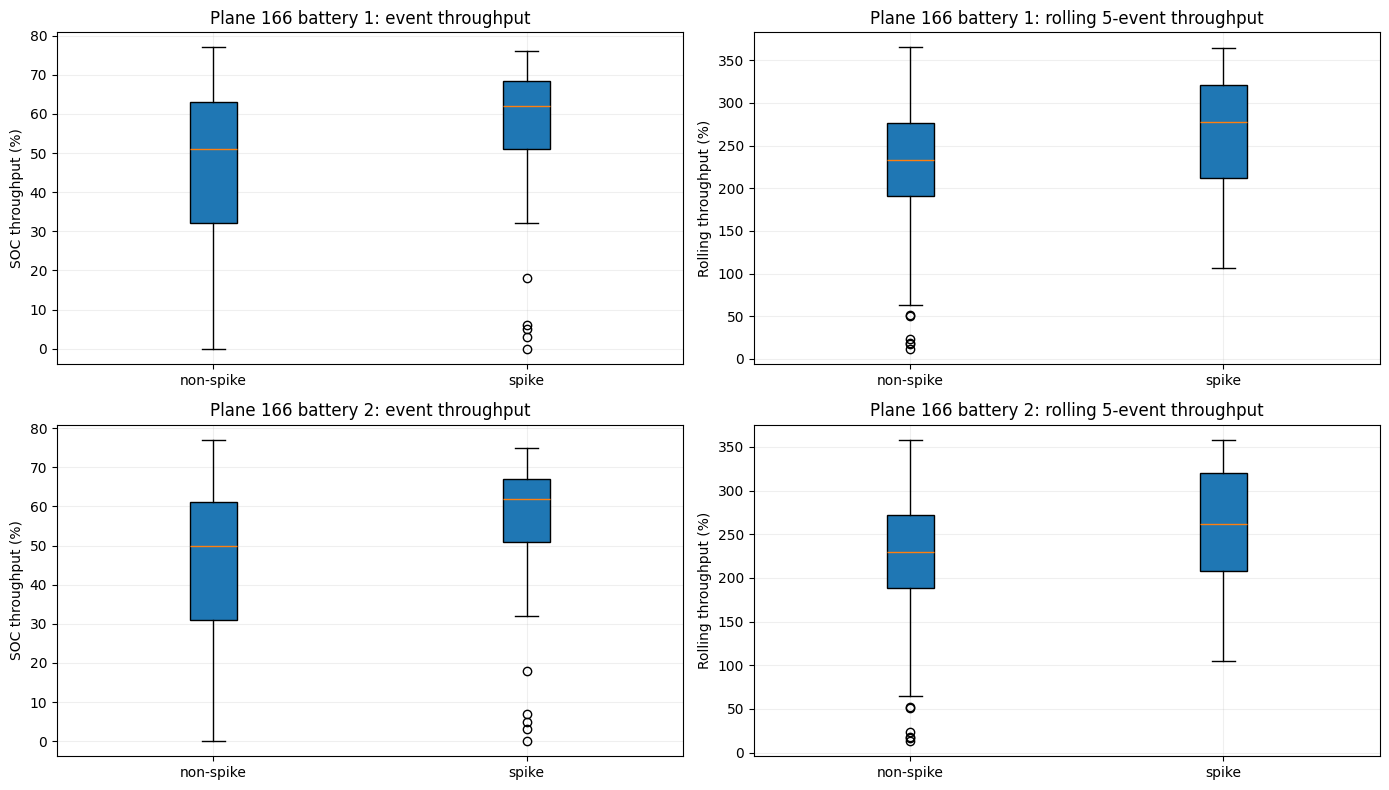

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row_idx, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].copy()
    spike = g['spike_up']

    axes[row_idx, 0].boxplot(
        [g.loc[~spike, 'soc_throughput_pct'].dropna(), g.loc[spike, 'soc_throughput_pct'].dropna()],
        labels=['non-spike', 'spike'],
        patch_artist=True,
    )
    axes[row_idx, 0].set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: event throughput')
    axes[row_idx, 0].set_ylabel('SOC throughput (%)')
    axes[row_idx, 0].grid(alpha=0.2)

    axes[row_idx, 1].boxplot(
        [g.loc[~spike, 'rolling_soc_throughput_5'].dropna(), g.loc[spike, 'rolling_soc_throughput_5'].dropna()],
        labels=['non-spike', 'spike'],
        patch_artist=True,
    )
    axes[row_idx, 1].set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: rolling 5-event throughput')
    axes[row_idx, 1].set_ylabel('Rolling throughput (%)')
    axes[row_idx, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Throughput by event type around spikes

This helps separate simple usage effects from charge-event estimator behavior.

In [10]:
event_type_summary = (
    focus.groupby(['battery_id', 'event_type'])
    .agg(
        n_events=('flight_id', 'size'),
        n_spikes=('spike_up', 'sum'),
        median_throughput=('soc_throughput_pct', 'median'),
        median_delta_soh=('delta_soh_pct', 'median'),
    )
    .reset_index()
)
display(event_type_summary.sort_values(['battery_id', 'event_type']))

,battery_id,event_type,n_events,n_spikes,median_throughput,median_delta_soh
0,1,charge,298,24,47.0,0.0
1,1,flight,189,3,54.0,0.0
2,1,mixed,5,1,60.0,0.0
3,1,other,61,7,65.0,0.0
4,2,charge,298,27,46.0,0.0
5,2,flight,189,3,53.0,0.0
6,2,mixed,5,0,61.0,0.0
7,2,other,61,7,64.0,0.0


## Largest upward SOH jumps

The key question is whether these top jumps all coincide with unusually extreme throughput.

In [11]:
top_spikes = (
    focus.loc[focus['spike_up'], [
        'battery_id',
        'event_datetime',
        'event_type',
        'delta_soh_pct',
        'soc_start_pct',
        'soc_end_pct',
        'soc_throughput_pct',
        'rolling_soc_throughput_5',
        'rolling_soc_throughput_10',
        'recent_soc_throughput_7d',
        'recent_soc_throughput_30d',
    ]]
    .sort_values(['battery_id', 'delta_soh_pct'], ascending=[True, False])
)
display(top_spikes.groupby('battery_id').head(12))

,battery_id,event_datetime,event_type,delta_soh_pct,soc_start_pct,soc_end_pct,soc_throughput_pct,rolling_soc_throughput_5,rolling_soc_throughput_10,recent_soc_throughput_7d,recent_soc_throughput_30d
307,1,2024-05-01 17:00:00,charge,29.0,81.0,99.0,18.0,128.0,387.0,618.0,3126.0
499,1,2024-06-10 19:00:00,charge,21.0,46.0,100.0,54.0,211.0,426.0,1291.0,6253.0
165,1,2023-10-23 17:00:00,charge,12.0,29.0,61.0,32.0,224.0,536.0,1276.0,3874.0
552,1,2025-12-02 17:35:00,charge,10.0,100.0,44.0,56.0,204.0,380.0,56.0,160.0
329,1,2024-05-05 02:50:00,charge,7.0,64.0,100.0,36.0,214.0,461.0,950.0,4020.0
142,1,2023-10-16 16:30:00,charge,6.0,91.0,96.0,5.0,172.0,413.0,1293.0,2993.0
210,1,2023-12-08 16:44:00,other,6.0,98.0,28.0,70.0,310.0,628.0,270.0,742.0
221,1,2023-12-15 17:05:00,charge,6.0,28.0,96.0,68.0,350.0,696.0,767.0,1509.0
117,1,2023-10-10 17:54:00,charge,5.0,36.0,98.0,62.0,325.0,606.0,266.0,2453.0
226,1,2023-12-16 21:15:00,charge,5.0,28.0,100.0,72.0,242.0,592.0,728.0,1694.0


## Short interpretation helper

This cell prints a compact summary so the notebook is easy to skim later.

In [12]:
for battery_id in [1, 2]:
    g = focus[focus['battery_id'].eq(battery_id)].copy()
    spikes = g[g['spike_up']]
    non_spikes = g[~g['spike_up']]
    print(f'Plane {PLANE_FOCUS} battery {battery_id}')
    print(f"  events: {len(g)} | upward spikes: {int(g['spike_up'].sum())}")
    print(f"  Spearman(delta SOH, event throughput): {g['delta_soh_pct'].corr(g['soc_throughput_pct'], method='spearman'):.3f}")
    print(f"  Spearman(delta SOH, rolling 5-event throughput): {g['delta_soh_pct'].corr(g['rolling_soc_throughput_5'], method='spearman'):.3f}")
    print(f"  Spearman(delta SOH, recent 30-day throughput): {g['delta_soh_pct'].corr(g['recent_soc_throughput_30d'], method='spearman'):.3f}")
    print(f"  Median event throughput spike vs non-spike: {spikes['soc_throughput_pct'].median():.1f} vs {non_spikes['soc_throughput_pct'].median():.1f}")
    print(f"  Median rolling 5-event throughput spike vs non-spike: {spikes['rolling_soc_throughput_5'].median():.1f} vs {non_spikes['rolling_soc_throughput_5'].median():.1f}")
    print(f"  Spearman(delta SOH, 30-day event count): {g['delta_soh_pct'].corr(g['recent_event_count_30d'], method='spearman'):.3f}")
    print(f"  Median 30-day event count spike vs non-spike: {spikes['recent_event_count_30d'].median():.1f} vs {non_spikes['recent_event_count_30d'].median():.1f}")
    print(f"  Spike event types: {spikes['event_type'].value_counts().to_dict()}")
    print()


Plane 166 battery 1
  events: 553 | upward spikes: 35
  Spearman(delta SOH, event throughput): 0.101
  Spearman(delta SOH, rolling 5-event throughput): 0.082
  Spearman(delta SOH, recent 30-day throughput): 0.040
  Median event throughput spike vs non-spike: 62.0 vs 51.0
  Median rolling 5-event throughput spike vs non-spike: 278.0 vs 233.0
  Spearman(delta SOH, 30-day event count): 0.036
  Median 30-day event count spike vs non-spike: 42.0 vs 60.0
  Spike event types: {'charge': 24, 'other': 7, 'flight': 3, 'mixed': 1}

Plane 166 battery 2
  events: 553 | upward spikes: 37
  Spearman(delta SOH, event throughput): 0.069
  Spearman(delta SOH, rolling 5-event throughput): 0.068
  Spearman(delta SOH, recent 30-day throughput): 0.038
  Median event throughput spike vs non-spike: 62.0 vs 50.0
  Median rolling 5-event throughput spike vs non-spike: 262.0 vs 229.5
  Spearman(delta SOH, 30-day event count): 0.034
  Median 30-day event count spike vs non-spike: 33.0 vs 60.0
  Spike event types:

## Reading the results

A few interpretations to keep in mind:

- If the correlations are weak, then high usage alone is probably **not** the full explanation.
- If spike events have only slightly higher throughput than non-spike events, throughput may be a contributing factor but not the main driver.
- If most spikes still concentrate in charging events, the result is more consistent with **estimator behavior during charge** than with true degradation from usage alone.
- If rolling recent throughput separates spikes better than current-event throughput, that suggests a **cumulative usage** effect rather than an event-local one.
- If recent event counts are weak or even lower for spike events, then simple usage frequency is probably **not** the main inflation mechanism either.